# $$\Huge \text{Team 14 Executive EDA}$$
# $$\text{Trilemma Foundation}$$

# $$ \text{1. Executive Summary} $$

This analysis evaluates whether event-level dominance metrics from the StatsBomb dataset meaningfully explain match outcomes and how these signals can inform prediction market pricing.

<br>
<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">
<br>

### Key Findings

**1. Shot quality is the strongest predictor of match outcome.**

Expected goal differential (`xg_diff`) alone explains nearly half of the variation in goal differential: **$ R^2 \approx 0.49$**

A simple logistic regression using only `xg_diff` achieves:
- AUC ≈ 0.87  
- Accuracy ≈ 0.79  

Adding shots on target and shot volume increases performance to:
- AUC ≈ 0.92  
- Accuracy ≈ 0.84  

Match outcomes are therefore strongly tied to measurable attacking superiority across quality, volume, and precision.

<br>
<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">
<br>

**2. Early dominance is highly informative.**

Using only first-half data, predictive performance remains strong (AUC ≈ 0.84). Even when applying full-game coefficients to first-half events, performance declines only modestly.

This suggests that the relationship between shot dominance and win probability is largely time-stable, supporting live probability updating during matches.

<br>
<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">
<br>

**3. Game state alters late-match signal strength.**

Shot quality remains stable across time windows, while shot volume and pressure become increasingly reactive in late-game and overtime periods.

Overtime appears structurally distinct and likely requires separate modeling treatment.

<br>
<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">
<br>

### Implications for Prediction Markets

- Shot quality (`xg_diff`) is the most structurally stable pricing signal.
- Combining shot quality and volume materially improves win probability estimation.
- Late-game volume metrics may be inflated by urgency.
- A two-stage framework (pre-match baseline plus in-match updating) is empirically justified.

Overall, match outcomes are strongly determined by observable on-ball dominance patterns. These signals are statistically robust, interpretable, and suitable for real-time prediction market applications.

<br>
<br>
<br>
<br>
<br>
<br>

---
---
# $$ \text{2. Data Retrieval} $$

In [1]:
### === IMPORTS === ###
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer

In [2]:
### === DATA LODA === ###
# ----------------------------------
# Statsbomb Event Data Retrieval
# ----------------------------------
EDA_DIR = Path.cwd()  # should be .../<parent folder name>/eda
PROJECT_ROOT = EDA_DIR.parent # .../<parent folder name>

STATSBOMB_DIR = PROJECT_ROOT / "data" / "Statsbomb" # .../<parent folder name>/data/Statsbomb
EVENTS_PATH = STATSBOMB_DIR / "events.parquet" # .../<parent folder name>/data/Statsbomb/events.parquet

events_scan = pl.scan_parquet(EVENTS_PATH)
events_df = pl.read_parquet(EVENTS_PATH)

---
## $ \text{2.1. Preprocessing: Custom Functions} $

### Function: `create_match_results_matrix()`
- Transforms raw event-level StatsBomb data into a compact **match × team** feature table for modeling. For each team in each match (or a specified time window), it aggregates attacking and control metrics (shots, xG, shots on target, pressures, passes, carries, dribbles, final-third entries), then derives **opponent (“against”)** totals and **differential features** (team minus opponent). It also adds a binary **win indicator** (Win=1, Loss=0, Draw=None) for downstream classification.

In [3]:
### === CUSTOM FUNCTIONS' INITIALIZATION === ###
# ------------------------------------------------------------
# Build feature df in time window(s) (same columns as full-game df)
# ------------------------------------------------------------
def create_match_results_matrix(e, m, ot=False):      
    
    # carry / dribble / pass volume
    team_vol = (
        e.group_by(["match_id","team"])
         .agg([
             (pl.col("type") == "Carry").sum().alias("n_carries"),
             (pl.col("type") == "Dribble").sum().alias("n_dribbles"),
             (pl.col("type") == "Pass").sum().alias("n_passes"),
             ((pl.col("type") == "Pass") & (pl.col("pass_outcome").is_null()))
                 .sum().alias("n_passes_complete"),
         ])
    )
    
    # shots + xg
    team_shots = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.len().alias("shots"))
    team_xg = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.col("shot_statsbomb_xg").sum().alias("xg_for"))
    
    # shots on target
    sot_outcomes = ["Goal", "Saved", "Saved to Post", "Saved Off Target"]
    team_sot = (
        e.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome").is_in(sot_outcomes)))
         .group_by(["match_id","team"])
         .agg(pl.len().alias("shots_on_target"))
    )
    
    # pressures
    team_press = e.filter(pl.col("type") == "Pressure").group_by(["match_id","team"]).agg(pl.len().alias("pressures"))
    
    # final third entries (pass/carry end x > 80)
    team_ft_pass = e.filter((pl.col("type")=="Pass") & (pl.col("pass_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_passes"))
    team_ft_carry = e.filter((pl.col("type")=="Carry") & (pl.col("carry_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_carries"))

    if ot:
        # ------------------------------------------------------------
        # Build spine from provided event window (e)
        # ------------------------------------------------------------
        spine = (
            e.select(["match_id","team"])
             .unique()
        )
        
        # ------------------------------------------------------------
        # Start from event-based spine instead of m
        # ------------------------------------------------------------
        df_h1 = (
            spine
            .join(m, on=["match_id","team"], how="left")
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    else:
        # start from m spine and join features
        df_h1 = (
            m
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    
    # add opponent ("against") + diffs (cast to signed first to avoid u64 underflow)
    df_h1 = df_h1.with_columns([
        pl.col("goals_scored").cast(pl.Int64),
        pl.col("shots").cast(pl.Int64),
        pl.col("shots_on_target").cast(pl.Int64),
        pl.col("final_third_entries").cast(pl.Int64),
        pl.col("pressures").cast(pl.Int64),
    ])
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("goals_scored").sum().over("match_id").alias("match_goals_total"),
            pl.col("shots").sum().over("match_id").alias("match_shots_total"),
            pl.col("shots_on_target").sum().over("match_id").alias("match_sot_total"),
            pl.col("xg_for").sum().over("match_id").alias("match_xg_total"),
            pl.col("final_third_entries").sum().over("match_id").alias("match_ft_total"),
            pl.col("pressures").sum().over("match_id").alias("match_press_total"),
        ])
        .with_columns([
            (pl.col("match_goals_total") - pl.col("goals_scored")).alias("goals_conceded"),
            (pl.col("match_shots_total") - pl.col("shots")).alias("shots_against"),
            (pl.col("match_sot_total") - pl.col("shots_on_target")).alias("sot_against"),
            (pl.col("match_xg_total") - pl.col("xg_for")).alias("xg_against"),
            (pl.col("match_ft_total") - pl.col("final_third_entries")).alias("final_third_against"),
            (pl.col("match_press_total") - pl.col("pressures")).alias("pressure_against"),
        ])
        .with_columns([
            (pl.col("goals_scored") - pl.col("goals_conceded")).alias("goal_diff"),
            (pl.col("shots") - pl.col("shots_against")).alias("shot_diff"),
            (pl.col("shots_on_target") - pl.col("sot_against")).alias("sot_diff"),
            (pl.col("xg_for") - pl.col("xg_against")).alias("xg_diff"),
            (pl.col("final_third_entries") - pl.col("final_third_against")).alias("final_third_diff"),
            (pl.col("pressures") - pl.col("pressure_against")).alias("pressure_diff"),
        ])
        .with_columns([
            pl.col("n_carries").fill_null(0).cast(pl.Int64),
            pl.col("n_dribbles").fill_null(0).cast(pl.Int64),
            pl.col("n_passes").fill_null(0).cast(pl.Int64),
            pl.col("n_passes_complete").fill_null(0).cast(pl.Int64),
            (pl.col("n_passes_complete") / pl.when(pl.col("n_passes") > 0)
                 .then(pl.col("n_passes"))
                 .otherwise(None)).alias("pass_completion_rate")
        ])
        .drop([
            "match_goals_total","match_shots_total","match_sot_total",
            "match_xg_total","match_ft_total","match_press_total"
        ])
    )
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("n_carries").cast(pl.Int64).alias("n_carries_i"),
            pl.col("n_dribbles").cast(pl.Int64).alias("n_dribbles_i"),
            pl.col("n_passes").cast(pl.Int64).alias("n_passes_i"),
            pl.col("n_passes_complete").cast(pl.Int64).alias("n_passes_complete_i"),
        ])
        .with_columns([
            pl.col("n_carries_i").sum().over("match_id").alias("match_total_carries"),
            pl.col("n_dribbles_i").sum().over("match_id").alias("match_total_dribbles"),
            pl.col("n_passes_i").sum().over("match_id").alias("match_total_passes"),
            pl.col("n_passes_complete_i").sum().over("match_id").alias("match_total_passes_complete"),
        ])
        .with_columns([
            (pl.col("match_total_carries") - pl.col("n_carries_i")).alias("carries_against"),
            (pl.col("match_total_dribbles") - pl.col("n_dribbles_i")).alias("dribbles_against"),
            (pl.col("match_total_passes") - pl.col("n_passes_i")).alias("passes_against"),
            (pl.col("match_total_passes_complete") - pl.col("n_passes_complete_i")).alias("passes_complete_against"),
        ])
        .with_columns([
            (pl.col("n_carries_i") - pl.col("carries_against")).alias("carry_diff"),
            (pl.col("n_dribbles_i") - pl.col("dribbles_against")).alias("dribble_diff"),
            (pl.col("n_passes_i") - pl.col("passes_against")).alias("pass_diff"),
            (pl.col("n_passes_complete_i") - pl.col("passes_complete_against")).alias("pass_complete_diff"),
        ])
        .drop([
            "n_carries_i","n_dribbles_i","n_passes_i","n_passes_complete_i",
            "match_total_carries","match_total_dribbles","match_total_passes","match_total_passes_complete",
        ])
    )

    # add binary win loss column. Ties are populated with 'None' for later filtering
    df_h1 = df_h1.with_columns(
        pl.when(pl.col("result") == "Win").then(pl.lit(1))
          .when(pl.col("result") == "Loss").then(pl.lit(0))
          .otherwise(None)
          .cast(pl.Int8)
          .alias("win")
    )
    
    return df_h1


# -------------------------------------------------------------------
# Other functions
# -------------------------------------------------------------------
    
# === BUILD CORRELATION COMPARISON FUNCTION ===
def corr_series(corr_df, target, features, label):
    cols = corr_df.columns
    i = cols.index(target)
    vals = corr_df.row(i)
    return pd.Series({c: float(v) for c, v in zip(cols, vals) if c in features}, name=label)

def plot_corrs(targets, corr_dfs, features=None, magnitude=False, figsize=(14, 5)):
    """
    targets: list[str]                       e.g. ["goal_diff", "xg_diff"]
    corr_dfs: dict[str, polars.DataFrame]    e.g. {"All": corr_df, "H1": corr_df_h1, "Q1+Q3": corr_df_q13, "Q4": corr_df_q4}
    features: list[str]                      x-axis features (sorted alphabetically for consistent order)
    """
    if features is None:
        features = ["goal_diff", "xg_diff", "sot_diff", "shot_diff", "final_third_diff", "pressure_diff"]
    # features = sorted(features)

    for target in targets:
        series_list = [
            corr_series(df, target, features, label)
            for label, df in corr_dfs.items()
        ]

        plot_df = pd.concat(series_list, axis=1).loc[features]
        plot_data = plot_df.abs() if magnitude else plot_df

        ax = plot_data.plot(kind="bar", figsize=figsize, width=0.8)
        if not magnitude:
            ax.axhline(0, linewidth=1)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", label_type="edge", padding=2, fontsize=7)

        ax.set_title(f"{'|corr|' if magnitude else 'corr'} with {target}")
        ax.set_ylabel(f"{'|corr|' if magnitude else 'corr'}")
        ax.set_xlabel("")
        ax.legend(title="")
        plt.xticks(rotation=0)
        plt.grid(True, which="major", axis="y", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()

# === FUNCTION TO PREPARE X AND y FOR MODELING: inputs = dataframe, feature vars (list); Returns = X (np.ndarray), y (np.ndarray) ===
def prepare_model_data(df, feature_cols):
    # print("Starting # of rows   :", df.shape[0])
    model_df = df.filter(pl.col("win").is_not_null())
    # print("Post filter # of rows:", model_df.shape[0])
    X = model_df.select(feature_cols).to_pandas()
    y = model_df.select("win").to_numpy().ravel()
    return X, y

# === CUSTOM FUNCTION TO SAVE MODEL PERFORMANCE METRICS FOR LATER COMPARISON ===
def cv_metrics(acc_scores, auc_scores, model_name):
    return pd.DataFrame([{
        "Model": model_name,
        "Accuracy Mean": np.mean(acc_scores),
        "Accuracy StD":  np.std(acc_scores),
        "AUC Mean": np.mean(auc_scores),
        "AUC StD":  np.std(auc_scores),
    }]).round(3)

# === CUSTOM BIC FUNCTION FOR MODEL SELECTION / EVALUATION ===
def compute_bic(X, y):
    X_const = sm.add_constant(X)
    model = sm.Logit(y, X_const).fit(disp=False)
    return model.bic, model

---
## $ \text{2.2. Preprocessing: Create Match Results Matrix}$
- Uses `create_match_results_matrix()` to create main dataset across all events for modeling. This function is used again in section 3 to create additional match result matrices. 

In [4]:
### === CREATE MATCH RESULTS TABLE === ###
# ----------------------------------
# Initiate match results table 
# ----------------------------------
match_results = (events_df.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome") == "Goal"))
    .group_by(["match_id", "team"]).agg(pl.len().alias("goals_scored")))
# print("MATCH RESULTS shape | rows = (# games)x(# teams):", match_results.shape)

# left join with unique match/team combo to add teams that did not score any goals
all_team_matches = (events_df.select(["match_id", "team"]).unique()) # All team–match combinations observed in events
match_results = (all_team_matches.join(match_results, on=["match_id", "team"], how="left").with_columns(pl.col("goals_scored").fill_null(0)))
# print("MATCH RESULTS Shape | rows = (# games)x(2 teams):", match_results.shape)

# ----------------------------------------
# === add match result column ===
# ----------------------------------------
# print("\n\n===== MATCH RESULT Counts =====")
match_results = (match_results.with_columns([pl.col("goals_scored").max().over("match_id").alias("goals_max"),pl.col("goals_scored").min().over("match_id").alias("goals_min"),])
    .with_columns(pl.when(pl.col("goals_max") == pl.col("goals_min")).then(pl.lit("Draw"))
        .when(pl.col("goals_scored") == pl.col("goals_max")).then(pl.lit("Win")).otherwise(pl.lit("Loss")).alias("result"))
    .drop(["goals_max", "goals_min"]).sort("match_id"))
# display(match_results.head(5))

In [5]:
### === initial match results function call on all events data === ###
df = create_match_results_matrix(events_df, match_results) 

<br>
<br>
<br>
<br>
<br>
<br>

---
---
# $$ \text{3. General Dataset Overview} $$

---
## $ \text{3.1 Signal Strength and Structural Relationships}$

### Core Finding: Shot-Based Dominance Drives Outcomes

Across match-level differentials, three attacking metrics dominate in their relationship with goal differential:

- **Expected Goal Differential (`xg_diff`)**: ρ ≈ 0.70  
- **Shots on Target Differential (`sot_diff`)**: ρ ≈ 0.69  
- **Shot Volume Differential (`shot_diff`)**: ρ ≈ 0.47  

A correlation of ρ = 0.70 implies:

$$
R^2 \approx 0.49
$$

meaning that nearly **half of the variation in goal differential is explained by expected goal differential alone**. In sports analytics, this represents an exceptionally strong single-feature relationship.

### Interpretation

Teams that generate higher-quality chances relative to their opponent win at substantially higher rates. Shot quality and shot precision (shots on target) carry more predictive signal than raw shot volume or territorial dominance.

These attacking metrics are also highly correlated with one another. Teams that create high-quality chances typically generate more total shots and more final third entries. This redundancy explains why even simple models using a small number of attacking metrics perform strongly.

### Prediction Market Implication

If pricing mechanisms rely primarily on scoreline, momentum heuristics, or aggregate volume without properly weighting shot quality, systematic inefficiencies may arise, particularly in matches where:

- The underlying `xg_diff` strongly favors one team but the scoreline does not  
- High-quality chances are created but not converted  
- A trailing team is statistically dominant in expected goals  

Expected goal differential therefore emerges as a natural baseline variable for probabilistic pricing in prediction markets.

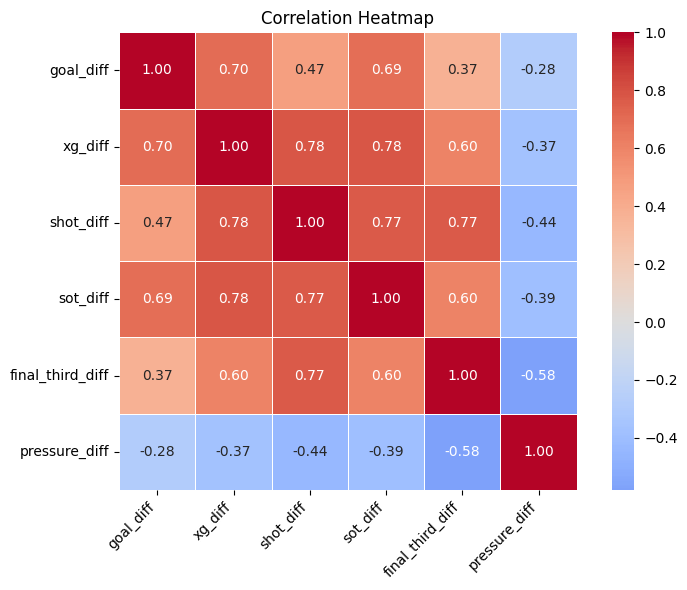

In [6]:
# === INITIAL CORRELATIONS TABLE ===
features = ["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"]
corr_df = df.select(features).corr()
corr_pd = corr_df.to_pandas() # Convert to pandas
corr_pd.index = features # Add row labels (so matrix is properly labeled)
corr_pd = corr_pd.round(2)
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_pd,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True,linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

---
## $ \text{3.2 Structural Instability Across Time Windows}$

### Core Finding: Game State Changes the Meaning of Events

When correlations are evaluated across different time windows (e.g., first half, fourth quarter, overtime), structural differences emerge:

- `xg_diff` remains the most stable predictor across all time segments  
- `shot_diff` weakens substantially in late-game periods  
- `final_third_diff` is moderately strong early but collapses late  
- `pressure_diff` is negatively correlated with goal differential and becomes increasingly reactive  
- In overtime, territorial and pressure metrics approach zero correlation with outcome  

### Interpretation

Early match dominance reflects underlying team strength.  
Late match dominance increasingly reflects urgency and game state.

As matches progress:

- Trailing teams shoot more  
- Trailing teams press more aggressively  
- Territory becomes desperation-driven rather than strength-driven  

Overtime appears to represent a structurally distinct regime characterized by fatigue, smaller sample sizes, and altered tactical incentives. In this environment, only shot quality maintains meaningful signal.

### Prediction Market Implication

Three implications follow:

1. **Late-game volume metrics may be inflated by urgency.**  
   Markets reacting to raw shot counts without context may overestimate comeback probability.

2. **Overtime should likely be modeled separately.**  
   Pooling overtime with regulation may distort predictive relationships.

3. **First-half dominance is highly informative.**  
   Correlations in the first half remain strong enough to justify live in-game updating models.

The persistence of `xg_diff` across time windows suggests that shot quality is the most structurally stable signal available for dynamic probability updating in prediction markets.

In [7]:
# === APPLY create_match_results_matrix() TO FILTERED DFS ===
### Event df filtering ###
# NOTE: this is just the starting events_df object                                       # 0) All events data
events_reg = events_df.filter(((pl.col("period") <= 2)))                                 # 0) Regulation:
events_first_half = events_reg.filter(pl.col("period") == 1)                             # 1) First half only
events_q1_q3 = events_reg.filter(((pl.col("period") == 1) & (pl.col("minute") <= 22)) |
                                 ((pl.col("period") == 2) & (pl.col("minute") <= 67)))   # 2) Q1 + Q3:
events_q4 = events_reg.filter(((pl.col("period") == 2) & (pl.col("minute") > 22)))       # 3) Q4:
events_ot = events_df.filter(((pl.col("period") > 2)))                                   # 4) Overtime:

### Apply Function ###
# df = create_match_results_matrix(events_df, match_results)                 # NOTE: already created/called in previous cell
df_h1 = create_match_results_matrix(events_first_half, match_results) 
df_q1_q3 = create_match_results_matrix(events_q1_q3, match_results) 
df_q4 = create_match_results_matrix(events_q4, match_results) 
df_ot = create_match_results_matrix(events_ot, match_results, ot=True) 
df_reg = create_match_results_matrix(events_reg, match_results) 

In [8]:
# ==== CALUCULATE CORRELATION MATRICES ON ALL FILTERED EVENTS DATA ===
features = ["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"]
corr_df = df.select(features).corr() # All events correlations
corr_df_h1 = df_h1.select(features).corr() # First Half events correlations
corr_df_q1_q3 = df_q1_q3.select(features).corr() # Q1 and Q3 events correlations
corr_df_q4 = df_q4.select(features).corr() # Q4 events correlations
corr_df_ot = df_ot.select(features).corr() # Overtime events correlations
corr_df_reg = df_reg.select(features).corr() # Regulation events correlations

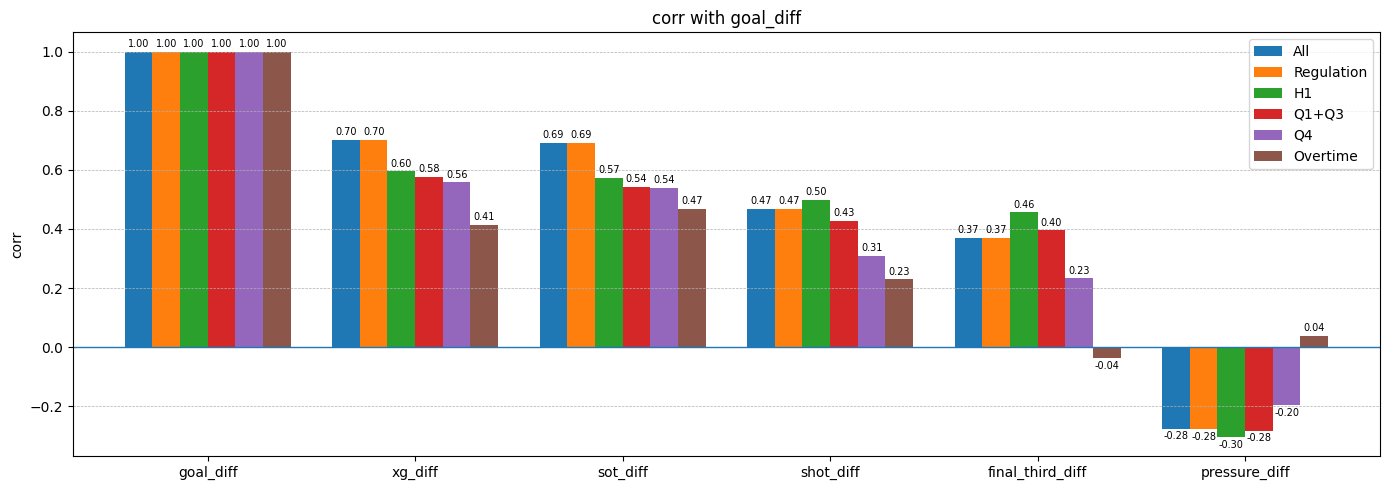

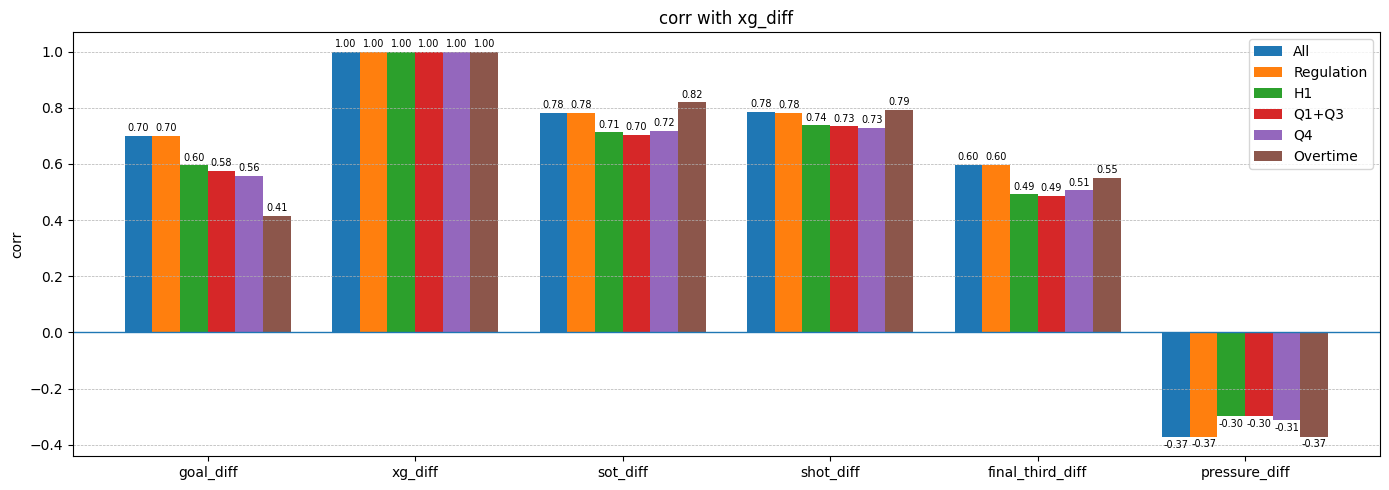

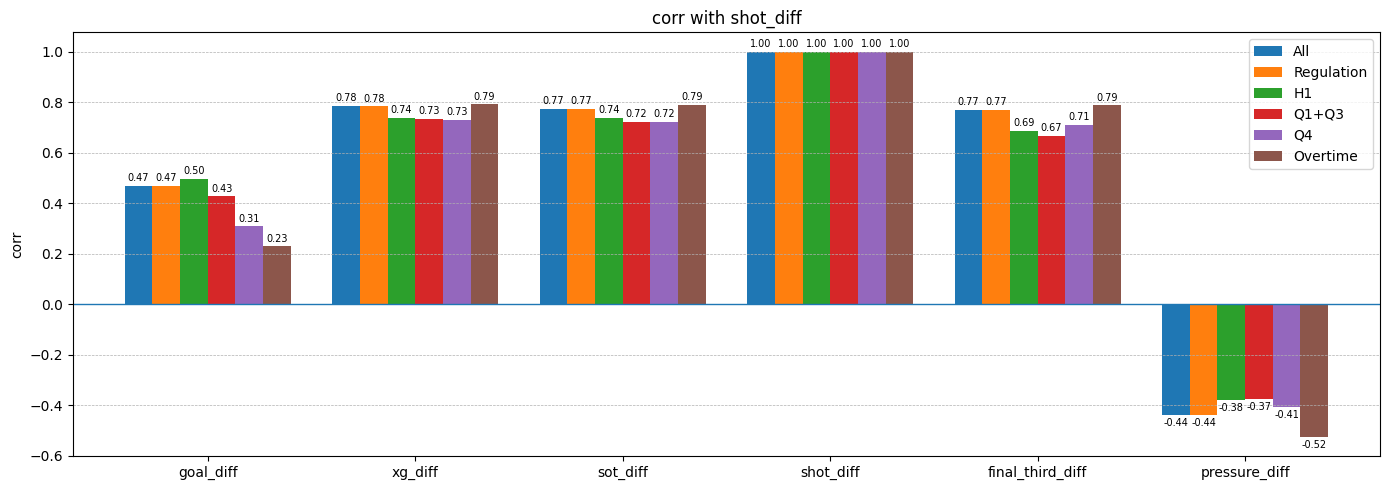

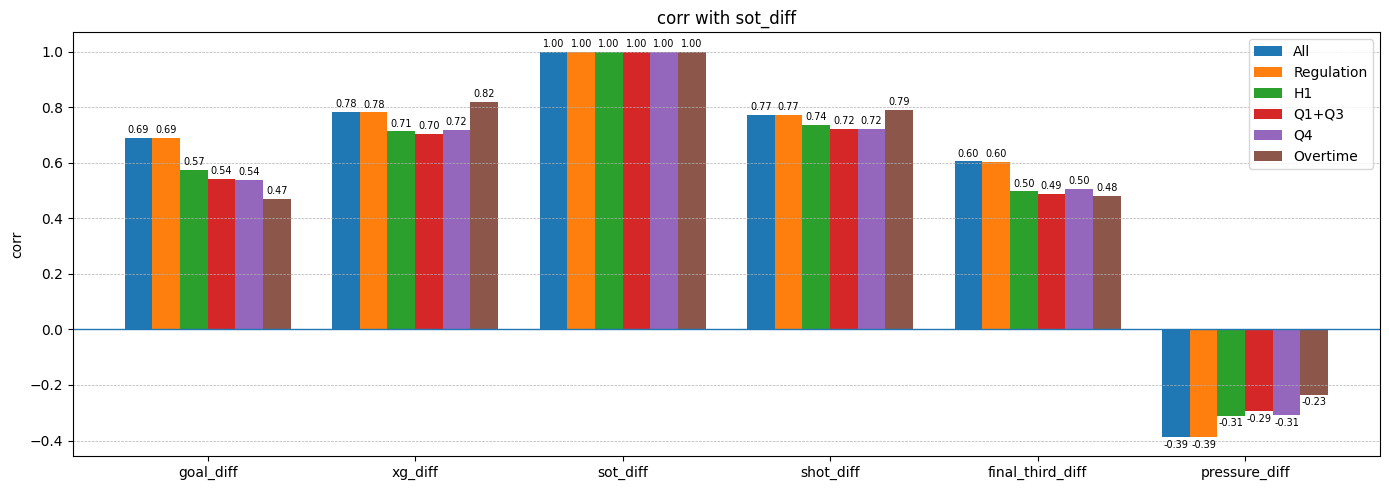

In [9]:
# === APPLY CORR COMPARISON FUNCTION corr_series() TO FILTERED DFs ===
corr_dfs = {"All": corr_df,"Regulation": corr_df_reg,"H1": corr_df_h1,"Q1+Q3": corr_df_q1_q3,"Q4": corr_df_q4,"Overtime": corr_df_ot}
plot_corrs(["goal_diff","xg_diff","shot_diff","sot_diff"],corr_dfs,magnitude=False)

---
## 3.3 Contextual Baseline: Global Match Structure

Before modeling event-level dominance, it is important to understand the broader structural characteristics of global football matches. See supporting EDA for additional details and analysis. 

### Overall Match Profile

Across competitions in the `matches.parquet` dataset:

- Average total goals ≈ 2.85 per match  
- Home win rate ≈ 45%  
- Away win rate ≈ 31%  
- Draw rate ≈ 23%  
- Scoreless draws ≈ 6%  

These results confirm a persistent home advantage and a moderately high scoring environment. Even prior to incorporating event-level information, baseline win probabilities are not symmetric.

<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">

### Competitive Structure

- ~35% of matches are decided by one goal  
- ~20% are 3+ goal blowouts  

While football is frequently tightly contested, decisive outcomes are not rare. Competitive balance varies across competitions, with some leagues and tournaments exhibiting higher parity and others displaying greater score dispersion.

Scoreline entropy analysis further indicates that certain competitions are structurally more unpredictable than others.

<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">

### League and Contextual Variation

Competitions exhibit distinct scoring identities and home-advantage magnitudes. Environmental and structural factors (such as tournament format, travel demands, and league style) are associated with measurable differences in scoring intensity and outcome distribution.

Scoring trends also fluctuate across eras rather than following a consistent long-term directional pattern.

<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">

### Modeling Implication

Football matches are not homogeneous events. Structural differences across competitions and contexts suggest that:

- Pre-match baseline probabilities should incorporate league-level effects.
- Predictability may vary by competition.
- Dynamic in-match updating should be layered on top of a contextual prior rather than applied in isolation.

This contextual baseline complements the event-level dominance modeling by establishing the macro structure within which match dynamics unfold.

<br>
<br>
<br>
<br>
<br>
<br>

---
---
# $$ \text{4. Predictive Modeling: Implications for Pricing}$$
The objective of this modeling section is not purely classification accuracy, but to understand:
- How strongly event-level dominance predicts match outcome
- How stable these relationships are across time segments
- Whether simple interpretable models perform competitively with more complex approaches
- What this implies for live prediction markets

All models use logistic regression for binary win/loss classification (draws excluded). Regulation-time data is used unless otherwise specified.

---
## Model 1 — Logistic Regression Using `xg_diff` Only

### Performance
- Accuracy ≈ 0.79  
- AUC ≈ 0.87  

### Interpretation

Using only expected goal differential, the model achieves strong discrimination power.  

The estimated slope implies that having a +1.0 expected goal differential on your opponent increases odds of winning by 4.6 times *(see footnote 1)*. Additionally, if the expected goal different is 0, then the model predicts that the team is 50% likely to win *(see footnote 2)*. This aligns with intuitive expectations — if teams are equal in expected goals, win probability is approximately even.

### Prediction Market Implication

Expected goal differential alone provides substantial predictive power.  

Any pricing system that does not properly incorporate shot quality is structurally inferior.  

In particular, situations where:
- A team dominates in xG but trails in score,
- Or where chance quality diverges from scoreline,

may represent temporary mispricing opportunities.

<br>
<br>

*Footnotes*

1: $+1.0 \text{ xG differential} \Rightarrow \text{odds of winning increase by } e^{1.53} \approx 4.6\times$

2: $P(\text{Win} \mid xg\_diff = 0) = 0.5$

In [10]:
# === MODEL 1 ===
# FILTER FOR WINS AND LOSES ONLY (REMOVE TIES)
df_reg_no_ties = (df_reg.filter(pl.col("result").is_in(["Win", "Loss"])))

# === LR MODEL | ONE FEATURE, REGULATION TIME ONLY ===
X, y = prepare_model_data(df_reg, feature_cols=["xg_diff"])
model1 = LogisticRegression()
model1.fit(X, y)
# Extract coefficients
model1_beta_0 = model1.intercept_[0]
model1_beta_1 = model1.coef_[0][0]
print("  Intercept (Beta_0):", round(model1_beta_0, 2))
print("Coefficient (Beta_1):", round(model1_beta_1, 2))
print("\n\n")

# accuracy and AUC
probs1 = model1.predict_proba(X)[:,1]
preds1 = model1.predict(X)
accuracy1 = accuracy_score(y, preds1)
auc1 = roc_auc_score(y, probs1)

# === CROSS VALIDATION LR MODEL | ONE FEATURE, REGULATION TIME ONLY ===
model1 = LogisticRegression()
# Results: Accuracy and AUC
acc_scores1 = cross_val_score(model1, X, y, cv=10, scoring="accuracy")
auc_scores1 = cross_val_score(model1, X, y, cv=10, scoring="roc_auc")
logreg_cv_results = cv_metrics(acc_scores1, auc_scores1, "LR (xg_diff only)")
display(logreg_cv_results)

  Intercept (Beta_0): -0.0
Coefficient (Beta_1): 1.53





,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,LR (xg_diff only),0.788,0.044,0.873,0.04


---
## Model 2 — Multi-Feature Logistic Regression (Forward Selection)

To evaluate whether attacking dominance metrics provide incremental predictive value beyond xG alone, forward selection using BIC was performed under two specifications:
1. All available features included
2. All xG-related features excluded

<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">

### Forward Selection (All Features Included)

#### Selected Features
- `sot_diff` (shots on target differential)
- `xg_diff` (expected goals differential)
- `shot_diff` (shot differential)

#### Performance
- Accuracy ≈ 0.843  
- AUC ≈ 0.922  

#### Interpretation

A small set of attacking dominance metrics explains the majority of outcome variability.  

The selected features capture three distinct dimensions of performance:

- **Shot quality** (`xg_diff`)
- **Shot accuracy / finishing pressure** (`sot_diff`)
- **Shot volume / territorial control** (`shot_diff`)

Despite high correlations among these variables, each contributes incremental predictive signal. The AUC improvement from 0.87 (xG-only model) to 0.92 indicates meaningful lift from combining quality, volume, and precision.

<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">

### Forward Selection (Excluding All xG Features)

#### Selected Features
- `sot_diff`
- `shot_diff`
- `carry_diff`
- `pass_diff`
- `pass_complete_diff`

#### Performance
- Accuracy ≈ 0.810  
- AUC ≈ 0.896  

#### Interpretation

Even without any xG-based variables, event-level dominance signals remain strongly predictive.

Shot volume and shots on target continue to anchor the model, while carries and passing differentials capture sustained attacking pressure and possession control.

Although predictive performance declines relative to the full model (AUC 0.896 vs 0.922), discrimination remains high. This confirms that xG is powerful but not the sole driver of predictability.

<hr style="width:25%; border-top:1px dotted #d8d8d8; margin-left:0;">

### Prediction Market Implication

Several structural conclusions follow:

1. **Match dominance is highly predictive of final results.**  
   Outcomes are strongly tied to measurable attacking superiority.

2. **Expected goals adds substantial predictive value, but it is not strictly necessary for strong discrimination.**  
   Markets that do not explicitly model xG can still approximate win probability through volume and possession metrics, though with reduced precision.

3. **A small number of interpretable metrics explain most outcome variation.**  
   Complex high-dimensional models are not required to achieve strong predictive performance.

4. **Multi-dimensional dominance matters.**  
   Shot quality, shot frequency, and attacking control each provide complementary information.

In short, match outcomes are largely determined by observable on-ball dominance patterns, and these signals are statistically robust, interpretable, and suitable for real-time probability updating.

In [11]:
# === MODEL 2 FORWARD SEARCH LR MODEL ===
# -------------------------------------------------------------------
# Model 2 Forward Selection Diff Vars only
# -------------------------------------------------------------------
candidates = [
    'xg_diff', 'xg_for', 'xg_against',
    'shots', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']
X, y = prepare_model_data(df_reg, feature_cols=candidates)
selected = []
remaining = candidates.copy()
current_bic = np.inf
while len(remaining) > 0:
    bic_with_candidates = []
    for candidate in remaining:
        X_candidate = X[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))
    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]
    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break
print("\nFinal selected variables (all features, including xG features):", selected, "\n\n\n")

# -------------------------------------------------------------------
# Model 2 Forward Selection All Vars
# -------------------------------------------------------------------
# === FORWARD SEARCH LR MODEL | ALL PREDICTORS | REGULATION TIME ===
candidates = [
    'shots', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']
X, y = prepare_model_data(df_reg, feature_cols=candidates)
selected = []
remaining = candidates.copy()
current_bic = np.inf
while len(remaining) > 0:
    bic_with_candidates = []
    for candidate in remaining:
        X_candidate = X[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))
    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]
    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break
print("\nFinal selected variables (all features, no xG features - diff, for, against, etc.):", selected, "\n\n\n")


# -------------------------------------------------------------------
# Model 2 Logistic Regression with Forward Selected Variables
# -------------------------------------------------------------------
# === LR MODEL PERFORMANCE | FORWARD SEARCH PREDICTORS | REGULATION TIME ===
features_selected = ["sot_diff", "xg_diff", "shot_diff"]
X_sel, y = prepare_model_data(df_reg, feature_cols=features_selected)
model2 = LogisticRegression()
acc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="accuracy")
auc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="roc_auc")
logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores2, auc_scores2, "Forward Search (all features)")
], ignore_index=True).drop_duplicates()

logreg_cv_results

# -------------------------------------------------------------------
# Model 2 Logistic Regression with Forward Selected Variables (excluding xG features)
# -------------------------------------------------------------------
# === LR MODEL PERFORMANCE | FORWARD SEARCH PREDICTORS | REGULATION TIME ===
features_selected = ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']
X_sel, y = prepare_model_data(df_reg, feature_cols=features_selected)
model2 = LogisticRegression()
acc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="accuracy")
auc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="roc_auc")
logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores2, auc_scores2, "Forward Search (no xG)")
], ignore_index=True).drop_duplicates()

display(logreg_cv_results)

Added: sot_diff | BIC: 4684.98
Added: xg_diff | BIC: 4304.99
Added: shot_diff | BIC: 3753.33

Final selected variables (all features, including xG features): ['sot_diff', 'xg_diff', 'shot_diff'] 



Added: sot_diff | BIC: 4684.98
Added: shot_diff | BIC: 4580.92
Added: carry_diff | BIC: 4577.77
Added: pass_diff | BIC: 4533.81
Added: pass_complete_diff | BIC: 4303.24

Final selected variables (all features, no xG features - diff, for, against, etc.): ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff'] 





,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,LR (xg_diff only),0.788,0.044,0.873,0.040
1,Forward Search (all features),0.843,0.027,0.922,0.020
2,Forward Search (no xG),0.810,0.030,0.896,0.022


---
## Model 3 — PCA + Logistic Regression

### Performance (Best k ≈ 10)
- Accuracy ≈ 0.80  
- AUC ≈ 0.88  

### Interpretation

Principal Component Analysis was used to address multicollinearity by transforming predictors into orthogonal components.

However, PCA does not outperform the simpler multi-feature model.

This demonstrates that multicollinearity does not meaningfully harm predictive performance in logistic regression when the objective is classification.

The primary tradeoff becomes interpretability:

- Forward selection model → 3 interpretable features
- PCA model → 7–10 latent components

### Prediction Market Implication

For live pricing systems, simpler interpretable models may be preferable to opaque dimensionality reduction techniques.

Dimensionality reduction does not materially improve predictive performance in this setting.

Top 10 Principal Components


,PC,Explained Variance Ratio,Cumulative Variance
0,1,0.581528,0.581528
1,2,0.075590,0.657118
2,3,0.070430,0.727548
3,4,0.050556,0.778105
4,5,0.045190,0.823294


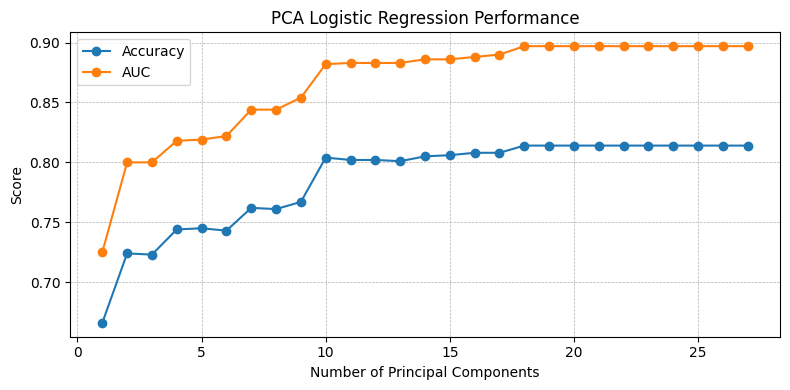

Best k = 10


,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,LR (xg_diff only),0.788,0.044,0.873,0.040
1,Forward Search (all features),0.843,0.027,0.922,0.020
2,Forward Search (no xG),0.810,0.030,0.896,0.022
3,PCA LogReg (k=10),0.804,0.028,0.882,0.027


In [12]:
# === PCA LR MODEL | ALL PREDICTORS | REGULATION TIME ===

# -------------------------------------------------
# 1. Run PCA Analysis
# -------------------------------------------------
# print("=== 1. MODEL 3 PCA Analysis ===")
# A. Select all numeric predictors except target
feature_cols = [
    'shots', 'xg_for', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'xg_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'xg_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']
X_raw, y = prepare_model_data(df_reg, feature_cols=candidates)

# B. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# C. Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# D. Explained variance
explained_variance = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)})
print("Top 10 Principal Components")
display(explained_variance.head(5))


# -------------------------------------------------
# 2. FIT PCA LR MODEL WITH TOP K PCs
# -------------------------------------------------
# print("\n\n=== 2. MODEL 3 FIT PCA LR MODEL WITH TOP K PCs ===")
results_pca = []
for k in range(1, explained_variance.shape[0] + 1):
    X_k = X_pca[:, :k]
    model = LogisticRegression()
    acc_scores = cross_val_score(model, X_k, y, cv=5, scoring="accuracy")
    auc_scores = cross_val_score(model, X_k, y, cv=5, scoring="roc_auc")
    results_pca.append({
        "n_components": k,
        "acc_mean": acc_scores.mean(),
        "acc_se": acc_scores.std(ddof=1) / np.sqrt(5),
        "auc_mean": auc_scores.mean(),
        "auc_se": auc_scores.std(ddof=1) / np.sqrt(5),
    })
pca_results_df = pd.DataFrame(results_pca).round(3)
# display(pca_results_df.head(18))

# plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pca_results_df["n_components"], pca_results_df["acc_mean"], marker='o', label="Accuracy")
ax.plot(pca_results_df["n_components"], pca_results_df["auc_mean"], marker='o', label="AUC")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Score")
ax.set_title("PCA Logistic Regression Performance")
ax.legend()
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 3. SAVE RESULTS FOR PCA MODEL WITH BEST K
# -------------------------------------------------
# print("\n\n=== 3. PCA MODEL WITH BEST K ===")

# choose best k by AUC elbow rule
best_k = 10
print("Best k =", best_k)

# recompute CV scores for best_k
X_best = X_pca[:, :best_k]
model = LogisticRegression()

# save results
acc_best = cross_val_score(model, X_best, y, cv=5, scoring="accuracy")
auc_best = cross_val_score(model, X_best, y, cv=5, scoring="roc_auc")
pca_best_row = cv_metrics(acc_best, auc_best, f"PCA LogReg (k={best_k})")

# append to running results df
logreg_cv_results = pd.concat([logreg_cv_results, pca_best_row], ignore_index=True).drop_duplicates()
display(logreg_cv_results)

---
## Model 4 — First Half Events Only

### Performance
- Accuracy ≈ 0.77  
- AUC ≈ 0.84  

### Interpretation

Using only first-half shot dominance metrics, predictive power remains strong.

Although correlations weaken relative to full-match data, early dominance still carries substantial signal.

This indicates that first-half event patterns meaningfully inform final outcome probability.

### Prediction Market Implication

At halftime, approximately 84% discrimination power is achievable using shot-based dominance metrics alone.

Early in-game markets that lag underlying xG or shot dominance may temporarily misprice win probability.

This result supports the feasibility of live updating frameworks based on early match events.

In [13]:
# -------------------------------------------------
# 1. LogReg Model on first half data only (train and test)
# -------------------------------------------------
features_selected = ["sot_diff", "xg_diff", "shot_diff"]
X_sel, y = prepare_model_data(df_h1, feature_cols=features_selected)

### Run and test model with the 3 predictors ###
model4 = LogisticRegression()

acc_scores4 = cross_val_score(model4, X_sel, y, cv=5, scoring="accuracy")
auc_scores4 = cross_val_score(model4, X_sel, y, cv=5, scoring="roc_auc")

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores4, auc_scores4, "LogReg H1")
], ignore_index=True).drop_duplicates()
display(logreg_cv_results)

,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,LR (xg_diff only),0.788,0.044,0.873,0.040
1,Forward Search (all features),0.843,0.027,0.922,0.020
2,Forward Search (no xG),0.810,0.030,0.896,0.022
3,PCA LogReg (k=10),0.804,0.028,0.882,0.027
4,LogReg H1,0.766,0.029,0.841,0.038


---
## Model 5 — Frozen Coefficient Test

### Setup
- Train on regulation-time data
- Test using first-half data
- No retraining

### Performance
- Accuracy ≈ 0.74  
- AUC ≈ 0.82  

### Interpretation

Performance declines only modestly when applying full-game coefficients to first-half data.

This suggests that the relationship between shot dominance and win probability is largely time-invariant.

In other words, the structural mapping from dominance → win probability remains stable across match segments.

### Prediction Market Implication

This stability supports a two-stage modeling framework:

1. Pre-match baseline probability  
2. In-match updating using shot dominance metrics  

The modest performance drop suggests that live updating can rely on structurally consistent relationships rather than fully re-estimating models at each time segment.

In [24]:
# -------------------------------------------------
# 1. Model 5: train on regulation data, test on first half data
# -------------------------------------------------
features_selected = ["sot_diff", "xg_diff", "shot_diff"]

### === TRAIN === ###
X_full, y_full = prepare_model_data(df_reg, feature_cols=features_selected) # Full-game training data
model5 = LogisticRegression() 
model5.fit(X_full, y_full) # Fit model once on ALL full-game data

### === TEST === ###
# First-half features
X_h1, y_h1  = prepare_model_data(df_h1, feature_cols=features_selected)

# Predict probabilities using full-game-trained model
y_pred_prob = model5.predict_proba(X_h1)[:, 1]
y_pred_class = model5.predict(X_h1)

# Compute metrics
acc_h1_frozen = accuracy_score(y_h1, y_pred_class)
auc_h1_frozen = roc_auc_score(y_h1, y_pred_prob)

acc_h1_frozen, auc_h1_frozen

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_h1_frozen, auc_h1_frozen, "LogReg Frozen: Full Game → H1")
], ignore_index=True).drop_duplicates()

display(logreg_cv_results.sort_values(["Accuracy Mean","AUC Mean"], ascending=False))

,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
1,Forward Search (all features),0.843,0.027,0.922,0.020
2,Forward Search (no xG),0.810,0.030,0.896,0.022
3,PCA LogReg (k=10),0.804,0.028,0.882,0.027
0,LR (xg_diff only),0.788,0.044,0.873,0.040
4,LogReg H1,0.766,0.029,0.841,0.038
5,LogReg Frozen: Full Game → H1,0.736,0.000,0.818,0.000


---
## Model Results Visualization

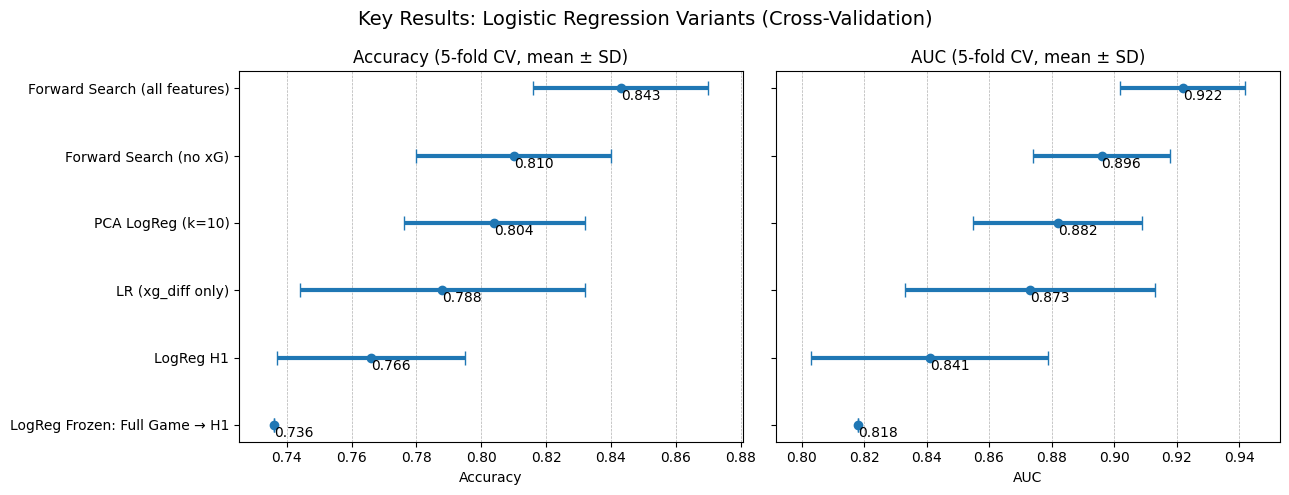

In [41]:
df = logreg_cv_results.copy()
df = df.rename(columns={"Model": "model","Accuracy Mean": "acc_mean","Accuracy StD": "acc_std","AUC Mean": "auc_mean","AUC StD": "auc_std",})
for c in ["acc_mean","acc_std","auc_mean","auc_std"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.sort_values(["auc_mean","acc_mean"], ascending=True).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
y = range(len(df))
axes[0].errorbar(df["acc_mean"], y, xerr=df["acc_std"], fmt="o", capsize=5, elinewidth=3, markersize=6)
axes[0].set_title("Accuracy (5-fold CV, mean ± SD)")
axes[0].set_xlabel("Accuracy")
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(df["model"])
axes[0].grid(True, axis="x", linestyle="--", linewidth=0.5)
axes[1].errorbar(df["auc_mean"], y, xerr=df["auc_std"], fmt="o", capsize=5, elinewidth=3, markersize=6)
axes[1].set_title("AUC (5-fold CV, mean ± SD)")
axes[1].set_xlabel("AUC")
axes[1].grid(True, axis="x", linestyle="--", linewidth=0.5)
for ax, m, s, fmt in [(axes[0],"acc_mean","acc_std","{:.3f}"), (axes[1],"auc_mean","auc_std","{:.3f}")]:
    lo = (df[m] - df[s]).min()
    hi = (df[m] + df[s]).max()
    pad = (hi - lo) * 0.08 if hi > lo else 0.02
    ax.set_xlim(lo - pad, hi + pad)
for i, r in df.iterrows():
    axes[0].text(r["acc_mean"], i - 0.18, f'{r["acc_mean"]:.3f}', fontsize=10)
    axes[1].text(r["auc_mean"], i - 0.18, f'{r["auc_mean"]:.3f}', fontsize=10)
fig.suptitle("Key Results: Logistic Regression Variants (Cross-Validation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Modeling Summary and Strategic Implications

Across all models, several structural conclusions emerge:

1. **Shot quality (xG differential) is the strongest single predictor of outcome.**
2. **Multi-dimensional attacking dominance improves prediction materially.**
3. **Multicollinearity does not degrade predictive performance in this setting.**
4. **First-half dominance remains highly informative.**
5. **The dominance → probability relationship is largely time-stable.**

Collectively, these findings support the development of a dynamic probability updating framework that integrates:

- Pre-match baseline strength
- Real-time shot quality and volume metrics
- Structural regime awareness (e.g., overtime separation)

<br>
<br>
<br>
<br>
<br>
<br>

---
---
# 6. Next Steps and Future Work

The findings from this exploratory analysis provide empirical support for moving toward a structured live prediction framework. Immediate next steps include:

### 1. Pre-Match Baseline Model
Develop a match-level baseline model using historical team strength metrics to estimate pre-kickoff win probabilities.

Preliminary match-level analysis suggests structural scoring differences across competitions; future modeling may incorporate league-level effects.

### 2. Dynamic In-Match Updating
Incorporate real-time shot dominance metrics, particularly `xg_diff`, `sot_diff`, and `shot_diff`, to update win probabilities throughout the match.

### 3. Market Comparison Analysis
Compare model-implied probabilities against prediction market odds to evaluate:
- Responsiveness to shot dominance
- Potential lag in price adjustment
- Situations where scoreline diverges from underlying xG patterns

### 4. Visualization and Dashboard Integration
Translate dynamic probability updates into a cumulative win-probability or xG trajectory dashboard suitable for live monitoring.

Collectively, these steps transition the project from descriptive analysis toward an operational, real-time pricing framework grounded in empirical event-level signal strength.